# Multimodal File Search

---

## An end-to-end multimodal RAG system on top of the Gemini API File Search tool

1. **Build a mixed-modal corpus** - real AI papers + matplotlib charts (wrapped as single-page PDFs).
2. **Create a File Search Store** and upload everything with rich `custom_metadata`.
3. **Run four progressively richer parts step by step**:
   - Part 1 - Text query across PDFs with **page-level citations**.
   - Part 2 - **Cross-modal query** that retrieves a chart PDF when asked for visual content.
   - Part 3 - **Metadata filter** to scope retrieval (year, modality, topic).
   - Part 4 - Multi-source research question answered across several papers.
4. **Inspect grounding chunks** to understand what the model retrieved (text snippet, page_number, custom_metadata).
5. **Clean up.**

## What's new in this update (recap)

- **Multimodal embeddings** via Gemini Embedding 2 - images and text in one vector space.
- **Custom metadata** - attach `key: string_value` labels on upload, filter at query time.
- **Page-level citations** - grounding chunks now expose `page_number`.

## Setup

You'll need a Gemini API key from [aistudio.google.com](https://aistudio.google.com/app/apikey).

**In Colab:** add it as a secret named `GEMINI_API_KEY` (key icon in the left sidebar → New secret → toggle notebook access).

**Locally:** export `GEMINI_API_KEY=...` before launching Jupyter.

In [1]:
%pip install -q --upgrade google-genai matplotlib requests pillow

In [2]:
import os, time, json, textwrap
from pathlib import Path

# ---- API key: Colab secret > env var > paste fallback ----
API_KEY = os.environ.get("GEMINI_API_KEY")
if not API_KEY:
    try:
        from google.colab import userdata
        API_KEY = userdata.get("GEMINI_API_KEY")
    except Exception:
        pass
if not API_KEY:
    import getpass
    API_KEY = getpass.getpass("Paste your GEMINI_API_KEY: ")

assert API_KEY, "No API key - set GEMINI_API_KEY env var or Colab secret."
os.environ["GEMINI_API_KEY"] = API_KEY

from google import genai
from google.genai import types

client = genai.Client(api_key=API_KEY)
MODEL = "gemini-2.5-flash"
print("client ready ·", MODEL)

client ready · gemini-2.5-flash


## 1) Build a mixed-modal corpus

We'll combine:

- **Two famous AI papers** as PDFs (text + embedded figures):
  - *Attention Is All You Need* (Vaswani et al., 2017) - the transformer paper.
  - *Vision Transformer* (Dosovitskiy et al., 2020) - ViT, a great visual paper.
- **Three single-page chart PDFs** rendered from matplotlib - same as a real spec sheet, report page, or insurance claim:
  - A quarterly revenue chart (with a clear Q3 dip).
  - A model-accuracy curve over training steps.
  - A simple system-architecture diagram.

This mirrors the real launch examples - insurance claims, spec sheets, scientific papers - where the visual content lives **inside PDFs**. The multimodal embedding indexes both the page text and the chart visuals, so a query that describes a chart can retrieve the page that contains it.

> **Why PDFs and not standalone PNGs?** The current File Search upload endpoint accepts document formats (PDF, MD, TXT, code, JSON). Visual content gets indexed when it lives inside a document. To attach a screenshot or product photo today, wrap it in a one-page PDF - that's exactly what we'll do for the charts below.

In [3]:
# Download papers
import requests

CORPUS = Path("./corpus")
CORPUS.mkdir(exist_ok=True)

PAPERS = [
    {
        "filename": "attention_is_all_you_need.pdf",
        "url": "https://arxiv.org/pdf/1706.03762",
        "meta": {
            "title": "Attention Is All You Need",
            "authors": "Vaswani et al.",
            "year": "2017",
            "topic": "transformer",
            "modality": "paper",
        },
    },
    {
        "filename": "vision_transformer.pdf",
        "url": "https://arxiv.org/pdf/2010.11929",
        "meta": {
            "title": "An Image is Worth 16x16 Words (ViT)",
            "authors": "Dosovitskiy et al.",
            "year": "2020",
            "topic": "vision",
            "modality": "paper",
        },
    },
]

for p in PAPERS:
    out = CORPUS / p["filename"]
    if not out.exists():
        print(f"downloading {p['filename']}...")
        r = requests.get(p["url"], timeout=60, headers={"User-Agent": "Mozilla/5.0"})
        out.write_bytes(r.content)
    print(f"  {p['filename']:35s} {out.stat().st_size/1024:.0f} KB")

  attention_is_all_you_need.pdf       2163 KB
  vision_transformer.pdf              3656 KB


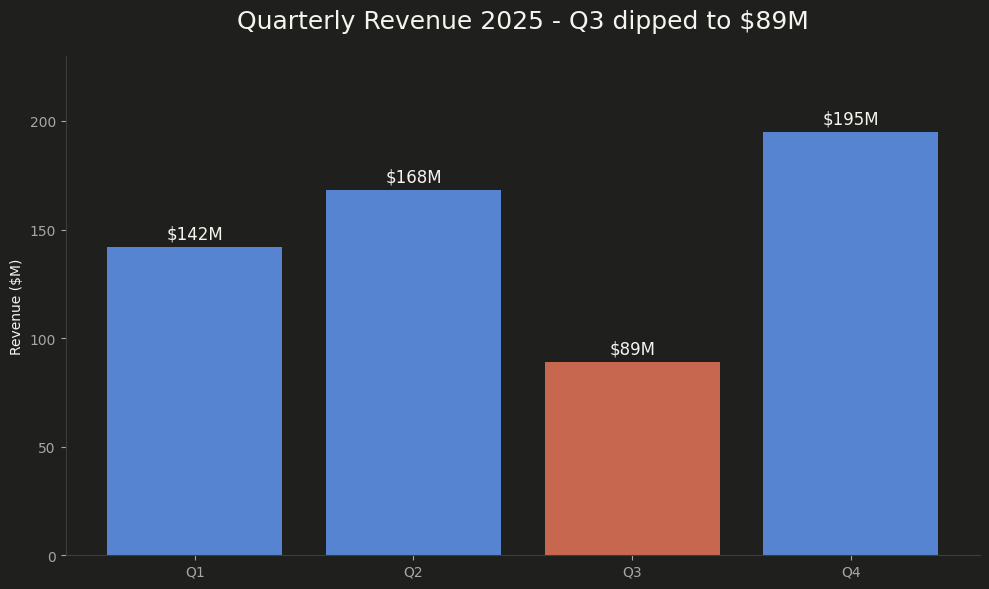

  rendered revenue_chart_q3_dip.pdf       13 KB


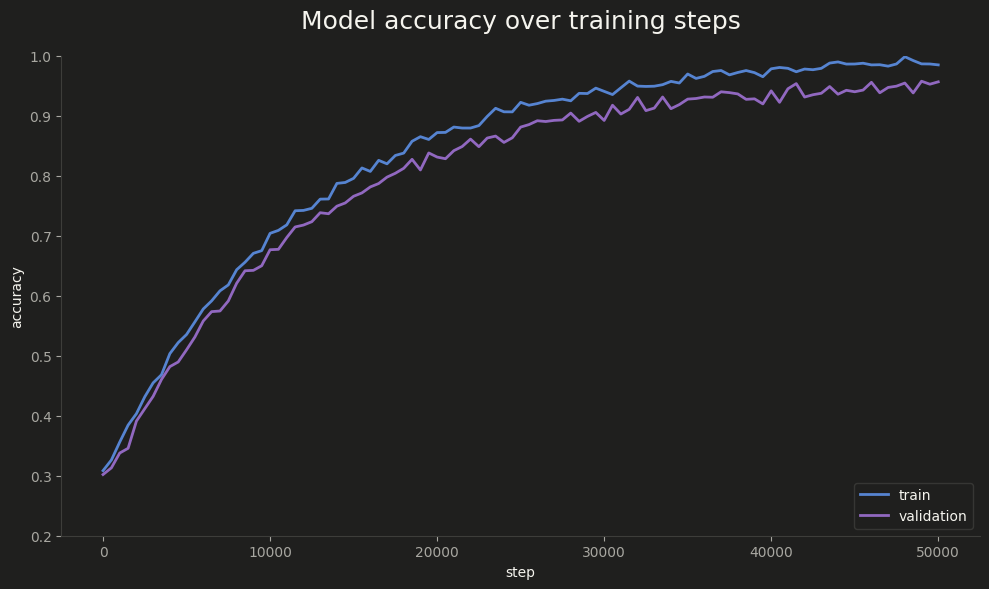

  rendered model_accuracy_curve.pdf       14 KB


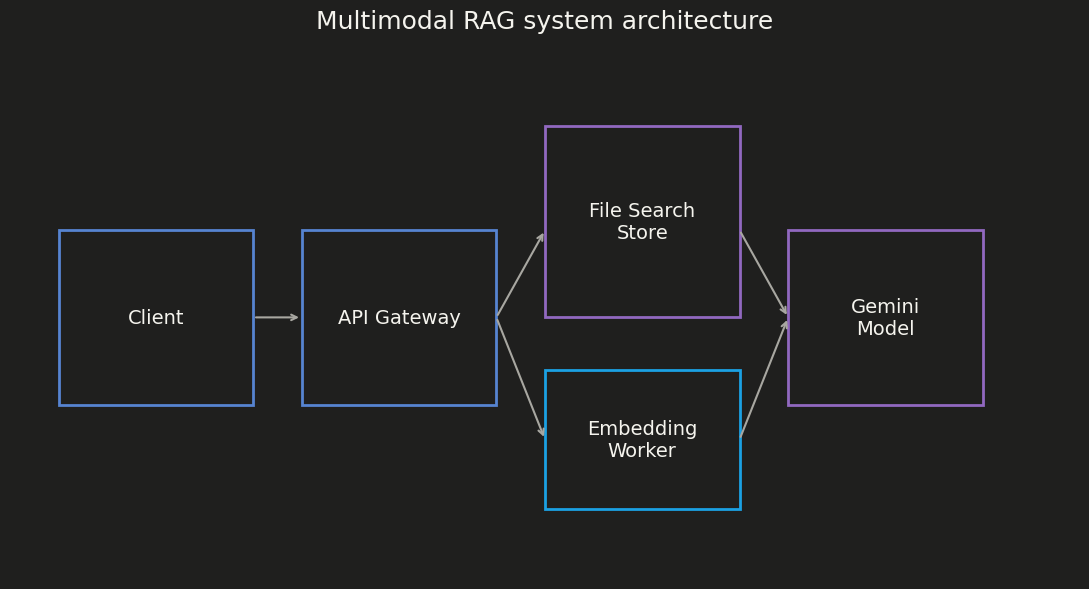

  rendered system_architecture.pdf        12 KB


In [4]:
# Render single-page chart PDFs with matplotlib.
# Each PDF will display inline in the notebook AND be uploaded to the store.
import matplotlib.pyplot as plt
import numpy as np

GEMINI_BLUE   = "#5684D1"
GEMINI_PURPLE = "#9168C0"
GEMINI_TEAL   = "#1BA1E3"
GEMINI_INK    = "#1F1F1E"
GEMINI_CREAM  = "#F5F4EE"
GEMINI_CORAL  = "#C7674F"

plt.rcParams.update({
    "axes.facecolor": GEMINI_INK,
    "figure.facecolor": GEMINI_INK,
    "savefig.facecolor": GEMINI_INK,
    "axes.edgecolor": "#3D3D3A",
    "axes.labelcolor": GEMINI_CREAM,
    "text.color": GEMINI_CREAM,
    "xtick.color": "#A8A7A1",
    "ytick.color": "#A8A7A1",
    "font.family": "sans-serif",
})

IMAGE_DEFS = [
    {
        "filename": "revenue_chart_q3_dip.pdf",
        "meta": {"title": "Quarterly Revenue Q3 Dip", "year": "2025",
                 "topic": "finance", "modality": "chart"},
        "build": "revenue",
    },
    {
        "filename": "model_accuracy_curve.pdf",
        "meta": {"title": "Model Accuracy Over Training Steps", "year": "2025",
                 "topic": "ml-metrics", "modality": "chart"},
        "build": "accuracy",
    },
    {
        "filename": "system_architecture.pdf",
        "meta": {"title": "System Architecture", "year": "2025",
                 "topic": "architecture", "modality": "chart"},
        "build": "architecture",
    },
]

def render_revenue(pdf_path):
    fig, ax = plt.subplots(figsize=(10, 6))
    quarters = ["Q1", "Q2", "Q3", "Q4"]
    revenue = [142, 168, 89, 195]
    colors = [GEMINI_BLUE, GEMINI_BLUE, GEMINI_CORAL, GEMINI_BLUE]
    bars = ax.bar(quarters, revenue, color=colors)
    for b, v in zip(bars, revenue):
        ax.text(b.get_x() + b.get_width()/2, v + 4, f"${v}M",
                ha="center", color=GEMINI_CREAM, fontsize=12)
    ax.set_title("Quarterly Revenue 2025 - Q3 dipped to $89M", fontsize=18, pad=20)
    ax.set_ylabel("Revenue ($M)")
    ax.set_ylim(0, 230)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    fig.savefig(pdf_path)
    plt.show()
    plt.close(fig)

def render_accuracy(pdf_path):
    fig, ax = plt.subplots(figsize=(10, 6))
    steps = np.arange(0, 50001, 500)
    base = 1 - np.exp(-steps / 12000) * 0.7
    train = np.clip(base + np.random.RandomState(7).normal(0, 0.005, len(steps)), 0, 1)
    val   = np.clip(base * 0.96 + np.random.RandomState(11).normal(0, 0.008, len(steps)), 0, 1)
    ax.plot(steps, train, color=GEMINI_BLUE,   linewidth=2, label="train")
    ax.plot(steps, val,   color=GEMINI_PURPLE, linewidth=2, label="validation")
    ax.set_title("Model accuracy over training steps", fontsize=18, pad=20)
    ax.set_xlabel("step")
    ax.set_ylabel("accuracy")
    ax.set_ylim(0.2, 1.0)
    ax.legend(loc="lower right", facecolor=GEMINI_INK,
              edgecolor="#3D3D3A", labelcolor=GEMINI_CREAM)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    fig.savefig(pdf_path)
    plt.show()
    plt.close(fig)

def render_architecture(pdf_path):
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.set_xlim(0, 11); ax.set_ylim(0, 6); ax.axis("off")
    nodes = [
        (0.5, 2.0, 2.0, 2.0, "Client",            GEMINI_BLUE),
        (3.0, 2.0, 2.0, 2.0, "API Gateway",       GEMINI_BLUE),
        (5.5, 3.0, 2.0, 2.2, "File Search\nStore", GEMINI_PURPLE),
        (5.5, 0.8, 2.0, 1.6, "Embedding\nWorker",  GEMINI_TEAL),
        (8.0, 2.0, 2.0, 2.0, "Gemini\nModel",      GEMINI_PURPLE),
    ]
    for x, y, w, h, label, color in nodes:
        ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=GEMINI_INK,
                                   edgecolor=color, linewidth=2))
        ax.text(x + w/2, y + h/2, label, ha="center", va="center",
                color=GEMINI_CREAM, fontsize=14)
    arrows = [(2.5, 3, 3.0, 3), (5.0, 3, 5.5, 4), (5.0, 3, 5.5, 1.6),
              (7.5, 4, 8.0, 3), (7.5, 1.6, 8.0, 3)]
    for x1, y1, x2, y2 in arrows:
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", color="#A8A7A1", lw=1.5))
    ax.set_title("Multimodal RAG system architecture",
                 fontsize=18, pad=20, color=GEMINI_CREAM)
    plt.tight_layout()
    fig.savefig(pdf_path)
    plt.show()
    plt.close(fig)

BUILDERS = {"revenue": render_revenue, "accuracy": render_accuracy,
            "architecture": render_architecture}

for d in IMAGE_DEFS:
    out = CORPUS / d["filename"]
    BUILDERS[d["build"]](out)
    print(f"  rendered {d['filename']:30s} {out.stat().st_size/1024:.0f} KB")

## 2) Create a File Search Store

A *File Search Store* is the managed vector store inside the Gemini API. Storage is free; you pay only for embedding tokens at ingest time.

In [5]:
STORE_NAME = "multimodal-rag"

# Remove any prior run of this experiment to keep things tidy
for s in client.file_search_stores.list():
    if s.display_name == STORE_NAME:
        client.file_search_stores.delete(name=s.name, config={"force": True})
        print(f"  cleaned up prior store: {s.name}")

store = client.file_search_stores.create(config={"display_name": STORE_NAME})
print(f"created · {store.name}")

created · fileSearchStores/multimodalrag-y3c9zr7r5til


## 3) Upload everything with `custom_metadata`

Same upload call for papers and chart PDFs. The new bit is the `custom_metadata` field - a list of `{"key": ..., "string_value": ...}` pairs we'll filter on later.

In [6]:
ALL_ITEMS = PAPERS + IMAGE_DEFS

ops = []
for item in ALL_ITEMS:
    path = CORPUS / item["filename"]
    op = client.file_search_stores.upload_to_file_search_store(
        file=str(path),
        file_search_store_name=store.name,
        config={
            "display_name": item["filename"],
            "custom_metadata": [
                {"key": k, "string_value": v} for k, v in item["meta"].items()
            ],
        },
    )
    ops.append((item["filename"], op))
    print(f"  uploading {item['filename']:35s} {item['meta']['modality']}")

# Wait for embedding to finish on each upload
print("\nwaiting for embedding...")
for name, op in ops:
    while not op.done:
        time.sleep(2)
        op = client.operations.get(op)
    print(f"  ✓ {name}")
print("\nall files embedded - store ready.")

  uploading attention_is_all_you_need.pdf       paper
  uploading vision_transformer.pdf              paper
  uploading revenue_chart_q3_dip.pdf            chart
  uploading model_accuracy_curve.pdf            chart
  uploading system_architecture.pdf             chart

waiting for embedding...
  ✓ attention_is_all_you_need.pdf
  ✓ vision_transformer.pdf
  ✓ revenue_chart_q3_dip.pdf
  ✓ model_accuracy_curve.pdf
  ✓ system_architecture.pdf

all files embedded - store ready.


### Helper: pretty-print a response with its grounding chunks

Every part below uses this. It shows the model's answer plus the chunks that grounded it - including `page_number`, `document_name`, custom_metadata, and a snippet of the retrieved text.

In [7]:
def show(response, label=None):
    """Pretty-print a generate_content response + its grounding chunks."""
    if label:
        print(f"\n{'='*72}\n{label}\n{'='*72}")
    print("\nANSWER:")
    print(textwrap.indent(textwrap.fill(response.text, 90), "  "))

    gm = response.candidates[0].grounding_metadata
    if not gm or not gm.grounding_chunks:
        print("\n(no grounding chunks - retrieval may have been skipped)")
        return
    print(f"\nGROUNDING CHUNKS ({len(gm.grounding_chunks)}):")
    for i, ch in enumerate(gm.grounding_chunks):
        rc = getattr(ch, "retrieved_context", None)
        if not rc:
            continue
        doc  = getattr(rc, "title", None) or getattr(rc, "document_name", "?")
        page = getattr(rc, "page_number", None)
        meta = getattr(rc, "custom_metadata", None)
        snippet = (getattr(rc, "text", "") or "").replace("\n", " ")[:140]
        page_str = f"page {page}" if page else "-"
        meta_str = ""
        if meta:
            kv = []
            for m in meta:
                k = getattr(m, "key", None); v = getattr(m, "string_value", None)
                if k and v:
                    kv.append(f"{k}={v}")
            if kv:
                meta_str = "  ·  " + ", ".join(kv)
        print(f"  [{i}] {doc}  ({page_str}){meta_str}")
        if snippet:
            print(f"        \"{snippet}…\"")

## Part 1 - Text query with page-level citations

Ask a question whose answer lives in the AI papers. The model retrieves the relevant chunks, answers, and exposes `page_number` on each grounding chunk.

In [8]:
query = "How does multi-head attention work, and why does it help over single-head attention?"

resp = client.models.generate_content(
    model=MODEL,
    contents=query,
    config=types.GenerateContentConfig(
        tools=[types.Tool(
            file_search=types.FileSearch(file_search_store_names=[store.name])
        )]
    ),
)
show(resp, "PART 1 · multi-head attention")


PART 1 · multi-head attention

ANSWER:
  Multi-head attention operates by performing several attention functions in parallel, which
  are referred to as "heads". Instead of using a single attention function with high-
  dimensional keys, values, and queries, multi-head attention linearly projects the queries,
  keys, and values multiple times (h times) using different learned linear projections.
  These projections reduce the dimensions of the queries and keys to $d_k$ and values to
  $d_v$.  For each of these projected sets of queries, keys, and values, a scaled dot-
  product attention function is computed in parallel. Each parallel attention operation
  produces a $d_v$-dimensional output value. The outputs from all these individual attention
  heads are then concatenated together. This concatenated result is subsequently passed
  through a final linear projection to produce the ultimate output. Despite running multiple
  heads, the overall computational cost of multi-head attentio

## Part 2 - Cross-modal query (retrieving a chart)

Now ask a question that should be answered by **a chart, not a paragraph**. The query describes the visual content (Q3 revenue dip); the multimodal embedding routes it to the chart PDF, and the model reads the numbers off the figure.

In [9]:
query = "Show me the chart where Q3 revenue dipped. What were the actual numbers?"

resp = client.models.generate_content(
    model=MODEL,
    contents=query,
    config=types.GenerateContentConfig(
        tools=[types.Tool(
            file_search=types.FileSearch(file_search_store_names=[store.name])
        )]
    ),
)
show(resp, "PART 2 · find the Q3 revenue dip chart")


PART 2 · find the Q3 revenue dip chart

ANSWER:
  A chart titled "Quarterly Revenue 2025" shows a dip in Q3 revenue. In Q3 2025, the revenue
  was $89M. Here are the actual revenue numbers for each quarter:  *   **Q1:** $168M *
  **Q2:** $142M *   **Q3:** $89M *   **Q4:** $195M

GROUNDING CHUNKS (4):
  [0] revenue_chart_q3_dip.pdf  (page 1)  ·  title=Quarterly Revenue Q3 Dip, year=2025, topic=finance, modality=chart
        "Revenue (\$M) 200 Quarterly Revenue 2025 - Q3 dipped to \$89M \$168M 150 \$142M 100 50 Q1 \$89M Q2 Q3 Q4 \$195M  …"
  [1] vision_transformer.pdf  (page 22)  ·  title=An Image is Worth 16x16 Words (ViT), authors=Dosovitskiy et al., year=2020, topic=vision, modality=paper
        " 74.1   |  99.3   |  92.7   |  61.0   |  80.9   |  82.5   |  95.6   |  85.2   |  75.3   |  70.3   |  56.1   |  41.9   |  74.7   |  64.9   | …"
  [2] model_accuracy_curve.pdf  (page 1)  ·  title=Model Accuracy Over Training Steps, year=2025, topic=ml-metrics, modality=chart
        "accurac

In [10]:
# Another cross-modal one - should retrieve the architecture diagram PDF
query = ("Describe the system architecture diagram in our internal docs. "
        "What components are there and how do they connect?")

resp = client.models.generate_content(
    model=MODEL,
    contents=query,
    config=types.GenerateContentConfig(
        tools=[types.Tool(
            file_search=types.FileSearch(file_search_store_names=[store.name])
        )]
    ),
)
show(resp, "PART 2b · describe the architecture diagram")


PART 2b · describe the architecture diagram

ANSWER:
  The internal documentation describes a "Multimodal RAG system architecture." This system
  includes several key components: Client, API Gateway, File Search, Store, Embedding,
  Worker, Gemini, and Model.  Here's a breakdown of the components and their likely
  connections within the system: *   **Client**: This is the entry point for users
  interacting with the system. It initiates requests. *   **API Gateway**: The API Gateway
  acts as the single entry point for all client requests, managing traffic and routing
  requests to the appropriate backend services. *   **File Search**: This component is
  responsible for searching through files, likely to retrieve relevant information based on
  user queries. *   **Store**: This component suggests a database or storage system where
  data, potentially including embeddings and raw files, is kept. *   **Embedding**: This
  component is responsible for generating embeddings, which are n

## Part 3 - Metadata filter

We tagged everything with `topic`, `year`, and `modality` on upload. Now we can scope retrieval at query time using the `metadata_filter` parameter.

The filter syntax is a simple expression on `custom_metadata` keys: e.g. `topic="transformer"` or `modality="paper"`.

In [11]:
# Filter: only search papers, skip the charts
query = "What architectural innovation does the Vision Transformer introduce vs CNNs?"

resp = client.models.generate_content(
    model=MODEL,
    contents=query,
    config=types.GenerateContentConfig(
        tools=[types.Tool(
            file_search=types.FileSearch(
                file_search_store_names=[store.name],
                metadata_filter='modality="paper" AND topic="vision"',
            )
        )]
    ),
)
show(resp, "PART 3 · filtered: modality=paper AND topic=vision")


PART 3 · filtered: modality=paper AND topic=vision

ANSWER:
  The Vision Transformer (ViT) introduces a fundamental architectural shift compared to
  Convolutional Neural Networks (CNNs) by eliminating the reliance on convolutional layers.
  Instead of using convolutions, ViT applies a standard Transformer directly to sequences of
  image patches for image classification tasks.  Here are the key architectural innovations:
  *   **Patching and Linear Embedding**: ViT splits an image into fixed-size, non-
  overlapping patches. Each patch is then flattened and linearly projected into a lower-
  dimensional embedding space. This sequence of linear embeddings of patches serves as the
  input to the Transformer encoder, similar to how tokens (word embeddings) are fed into a
  Transformer in natural language processing (NLP). *   **Absence of Convolutional Layers**:
  Unlike CNNs, which inherently use convolutional filters to capture local features and
  hierarchical representations, ViT en

In [12]:
# Same store, but scope to chart PDFs only
query = "What internal charts and diagrams do we have? Briefly describe each."

resp = client.models.generate_content(
    model=MODEL,
    contents=query,
    config=types.GenerateContentConfig(
        tools=[types.Tool(
            file_search=types.FileSearch(
                file_search_store_names=[store.name],
                metadata_filter='modality="chart"',
            )
        )]
    ),
)
show(resp, "PART 3b · filtered: modality=chart")


PART 3b · filtered: modality=chart

ANSWER:
  We have several internal charts and diagrams:  *   **Multimodal RAG system architecture
  diagram**: This diagram illustrates the components of the Multimodal RAG system, including
  the Client, API Gateway, File Search, Store, Embedding, Worker, and Gemini Model. *
  **Quarterly Revenue 2025 chart**: This chart displays the quarterly revenue in millions of
  dollars for 2025. It indicates that Q3 revenue dipped to $89 million, while Q1 was $168
  million, Q2 was $142 million, and Q4 was $195 million. *   **Model accuracy over training
  steps chart**: This chart shows the accuracy of a model (both train and validation
  accuracy) as it progresses through various training steps.

GROUNDING CHUNKS (3):
  [0] system_architecture.pdf  (page 1)  ·  title=System Architecture, year=2025, topic=architecture, modality=chart
        "Client Multimodal RAG system architecture API Gateway File Search Store Embedding Worker Gemini Model  …"
  [1] reve

## Part 4 - Multi-source research question

This is where File Search starts to feel like a real research assistant. Ask a question that requires combining information from **multiple papers** - the model retrieves chunks from each and synthesizes.

In [13]:
query = (
    "How does the transformer's attention mechanism (Vaswani 2017) get adapted "
    "for vision in the ViT paper (Dosovitskiy 2020)? What changed in the input pipeline?"
)

resp = client.models.generate_content(
    model=MODEL,
    contents=query,
    config=types.GenerateContentConfig(
        tools=[types.Tool(
            file_search=types.FileSearch(
                file_search_store_names=[store.name],
                metadata_filter='modality="paper"',
                top_k=8,  # widen retrieval for multi-paper synthesis
            )
        )]
    ),
)
show(resp, "PART 4 · cross-paper synthesis")


PART 4 · cross-paper synthesis

ANSWER:
  In the Vision Transformer (ViT) paper by Dosovitskiy et al. (2020), the attention
  mechanism from the original Transformer (Vaswani et al., 2017) is adapted for vision tasks
  by fundamentally changing how image data is prepared and presented to the model, rather
  than altering the core multi-head self-attention mechanism itself. The Transformer encoder
  structure, comprising alternating layers of multi-headed self-attention (MSA) and MLP
  blocks, along with Layer Normalization before each block and residual connections after
  each block, is largely preserved.  The significant changes occur in the input pipeline to
  enable the Transformer to process 2D images: *   **Image to Patches:** Instead of a 1D
  sequence of token embeddings, the ViT takes a 2D image and reshapes it into a sequence of
  flattened 2D patches. These image patches are treated in the same manner as word tokens in
  Natural Language Processing (NLP) applications. If an

## Part 5 - Raw inspection: where did each chunk come from?

Sometimes the grounding chunk is more useful than the answer. Here we ask a deliberately broad question and list every chunk the retriever pulled - with its page number and the metadata we attached at upload.

In [14]:
query = "Anywhere in the corpus where you see the word 'attention', list each source."

resp = client.models.generate_content(
    model=MODEL,
    contents=query,
    config=types.GenerateContentConfig(
        tools=[types.Tool(
            file_search=types.FileSearch(
                file_search_store_names=[store.name],
                top_k=10,
            )
        )]
    ),
)
show(resp, "PART 5 · broad retrieval with top_k=10")


PART 5 · broad retrieval with top_k=10

ANSWER:
  The word 'attention' appears in the following sources:  *   attention_is_all_you_need.pdf
  *   vision_transformer.pdf

GROUNDING CHUNKS (10):
  [0] attention_is_all_you_need.pdf  (page 13)  ·  title=Attention Is All You Need, authors=Vaswani et al., year=2017, topic=transformer, modality=paper
        "the 51st Annual Meeting of the ACL (Volume 1: Long Papers), pages 434-443. ACL, August 2013. 12  Attention Visualizations a spirit that a ma…"
  [1] attention_is_all_you_need.pdf  (page 5)  ·  title=Attention Is All You Need, authors=Vaswani et al., year=2017, topic=transformer, modality=paper
        "Applications of Attention in our Model The Transformer uses multi-head attention in three different ways:  In "encoder-decoder attention" la…"
  [2] attention_is_all_you_need.pdf  (page 12)  ·  title=Attention Is All You Need, authors=Vaswani et al., year=2017, topic=transformer, modality=paper
        "Sukhbaatar, Arthur Szlam, Jason Wes

## What you can do next

Now that you've seen the surface, three good ways to push further:

1. **Drop your own corpus in.** Mix internal PDFs, screenshots-wrapped-as-PDFs, product spec sheets, scanned forms - all into one store. The same `upload_to_file_search_store` call handles them.
2. **Use metadata for multi-tenancy.** Tag each document with `tenant_id` on upload. At query time, set `metadata_filter='tenant_id="acme-corp"'` to enforce isolation at retrieval - no separate indexes needed.
3. **Compare against your hand-rolled stack.** Run the same queries against your existing pgvector + custom embedding setup and benchmark recall, latency, and total cost. (That's the next video.)

## Pricing recap

- Files cap at **100 MB** each.
- Free tier: **1 GB** total storage.
- Vector storage: **free.**
- Query-time embeddings: **free.**
- Ingest embeddings: standard Gemini Embedding rate.
- Source files auto-delete after **48 hours** (vectors remain).

## Cleanup

Delete the expeiment store to keep your project tidy.

In [15]:
client.file_search_stores.delete(name=store.name, config={"force": True})
print(f"deleted store · {store.name}")

deleted store · fileSearchStores/multimodalrag-y3c9zr7r5til


---

**Update reference:** [Google blog · May 2026](https://blog.google/innovation-and-ai/technology/developers-tools/expanded-gemini-api-file-search-multimodal-rag/)

**Docs:** [Gemini File Search API reference](https://ai.google.dev/gemini-api/docs/file-search)